# Session Index and Trial Catalog for Monkey N

This notebook converts the NWB-level exploratory outputs into a clean, decoder-ready metadata layer.

## Objectives
1. Load the outputs generated by Notebook 01 (EDA).
2. Build a canonical session index.
3. Extract and standardize trial tables from all NWB sessions.
4. Summarize target-style composition, trial timing, and session-level consistency.
5. Export tables for later decoding and adaptive-threshold notebooks.

## Inputs
- `/kaggle/working/tables_eda/session_inventory.csv`
- `/kaggle/working/tables_eda/nwb_session_summary.csv`
- `/kaggle/input/datasets/katakuricharlotte/dandi-dataset/001201/sub-Monkey-N/*.nwb`

## Outputs
- Session master table
- Trial catalog across all sessions
- Session-level trial summary
- QC figures for longitudinal and task-structure analysis

In [6]:
!pip install pynwb h5py

In [7]:
import os
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from pynwb import NWBHDF5IO

In [8]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "axes.linewidth": 1.2,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "grid.linestyle": ":",
    "grid.linewidth": 0.7,
    "grid.alpha": 0.85,
})

def paper_axes(ax):
    ax.minorticks_on()
    ax.grid(True, which="major", linestyle=":", linewidth=0.8)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.7)
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
    ax.tick_params(which="both", direction="in", top=True, right=True)

## Paths

This notebook reuses the exact Kaggle dataset path and the generated EDA outputs from Notebook 01.

In [9]:
DATASET_DIR = Path("/kaggle/input/datasets/katakuricharlotte/dandi-dataset/001201/sub-Monkey-N")

EDA_TABLE_DIR = Path("/kaggle/input/datasets/katakuricharlotte/dandi-eda-files/tables_eda")
EDA_META_DIR = Path("/kaggle/input/datasets/katakuricharlotte/dandi-eda-files/meta_eda")

WORK_ROOT = Path("/kaggle/working")
OUT_TABLE_DIR = WORK_ROOT / "tables_session_index"
OUT_FIG_DIR = WORK_ROOT / "figures_session_index"
OUT_META_DIR = WORK_ROOT / "meta_session_index"

OUT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
OUT_FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_META_DIR.mkdir(parents=True, exist_ok=True)

SESSION_INVENTORY_CSV = EDA_TABLE_DIR / "session_inventory.csv"
SESSION_SUMMARY_CSV = EDA_TABLE_DIR / "nwb_session_summary.csv"

print("DATASET_DIR:", DATASET_DIR)
print("SESSION_INVENTORY_CSV:", SESSION_INVENTORY_CSV)
print("SESSION_SUMMARY_CSV:", SESSION_SUMMARY_CSV)

DATASET_DIR: /kaggle/input/datasets/katakuricharlotte/dandi-dataset/001201/sub-Monkey-N
SESSION_INVENTORY_CSV: /kaggle/input/datasets/katakuricharlotte/dandi-eda-files/tables_eda/session_inventory.csv
SESSION_SUMMARY_CSV: /kaggle/input/datasets/katakuricharlotte/dandi-eda-files/tables_eda/nwb_session_summary.csv


In [10]:
assert DATASET_DIR.exists(), f"Missing dataset directory: {DATASET_DIR}"
assert SESSION_INVENTORY_CSV.exists(), f"Missing EDA file: {SESSION_INVENTORY_CSV}"
assert SESSION_SUMMARY_CSV.exists(), f"Missing EDA file: {SESSION_SUMMARY_CSV}"

inventory_df = pd.read_csv(SESSION_INVENTORY_CSV)
session_df = pd.read_csv(SESSION_SUMMARY_CSV)

inventory_df["session_date"] = pd.to_datetime(inventory_df["session_date"], errors="coerce")
session_df["session_date"] = pd.to_datetime(session_df["session_date"], errors="coerce")

print("inventory_df:", inventory_df.shape)
print("session_df:", session_df.shape)

display(inventory_df.head())
display(session_df.head())

inventory_df: (312, 7)
session_df: (312, 29)


,file_name,file_path,session_date,session_date_str,file_size_mb,session_index,days_since_first_session
0,sub-Monkey-N_ses-20200127_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-01-27,2020-01-27,42.920137,1,0
1,sub-Monkey-N_ses-20200130_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-01-30,2020-01-30,41.831490,2,3
2,sub-Monkey-N_ses-20200204_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-04,2020-02-04,41.058443,3,8
3,sub-Monkey-N_ses-20200205_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-05,2020-02-05,41.258791,4,9
4,sub-Monkey-N_ses-20200206_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-06,2020-02-06,41.851608,5,10


,file_name,file_path,session_date_from_name,identifier,session_description,session_start_time,institution,lab,subject_id,subject_species,...,electrodes_present,n_trials,n_units,n_electrodes,trial_columns,unit_columns,electrode_columns,session_date,session_index,days_since_first_session
0,sub-Monkey-N_ses-20200127_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-01-27,2020-01-27_CO_nwb,Neural and behavioral data for target style CO,2020-01-27 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,True,375,0,96,"['start_time', 'stop_time', 'trial_number', 't...",[],"['location', 'group', 'group_name', 'array_nam...",2020-01-27,1,0
1,sub-Monkey-N_ses-20200130_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-01-30,2020-01-30_CO_nwb,Neural and behavioral data for target style CO,2020-01-30 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,True,375,0,96,"['start_time', 'stop_time', 'trial_number', 't...",[],"['location', 'group', 'group_name', 'array_nam...",2020-01-30,2,3
2,sub-Monkey-N_ses-20200204_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-04,2020-02-04_CO_nwb,Neural and behavioral data for target style CO,2020-02-04 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,True,375,0,96,"['start_time', 'stop_time', 'trial_number', 't...",[],"['location', 'group', 'group_name', 'array_nam...",2020-02-04,3,8
3,sub-Monkey-N_ses-20200205_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-05,2020-02-05_CO_nwb,Neural and behavioral data for target style CO,2020-02-05 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,True,375,0,96,"['start_time', 'stop_time', 'trial_number', 't...",[],"['location', 'group', 'group_name', 'array_nam...",2020-02-05,4,9
4,sub-Monkey-N_ses-20200206_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-06,2020-02-06_CO_nwb,Neural and behavioral data for target style CO,2020-02-06 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,True,375,0,96,"['start_time', 'stop_time', 'trial_number', 't...",[],"['location', 'group', 'group_name', 'array_nam...",2020-02-06,5,10


In [11]:
def extract_session_date_from_name(file_name):
    m = re.search(r"_ses-(\d{8})_", str(file_name))
    if m is None:
        return pd.NaT
    return pd.to_datetime(m.group(1), format="%Y%m%d", errors="coerce")

def infer_target_style(row):
    vals = []
    for col in ["session_description", "identifier", "file_name"]:
        val = row.get(col, None)
        if pd.notna(val):
            vals.append(str(val).lower())

    joined = " ".join(vals)

    if " target style co" in joined or "_co_" in joined or joined.endswith("_co_nwb"):
        return "CO"
    if " target style rd" in joined or "_rd_" in joined or joined.endswith("_rd_nwb"):
        return "RD"

    m = re.search(r"target style\s+([a-z0-9]+)", joined)
    if m:
        return m.group(1).upper()

    return "UNKNOWN"

def safe_read_trials(nwb_path):
    with NWBHDF5IO(str(nwb_path), mode="r", load_namespaces=True) as io:
        nwb = io.read()
        if nwb.trials is None:
            return pd.DataFrame()
        return nwb.trials.to_dataframe().reset_index()

## Build the session master table

This table becomes the canonical reference for every later notebook.

In [12]:
session_master_df = session_df.copy()

session_master_df["file_name"] = session_master_df["file_name"].astype(str)
session_master_df["session_date"] = session_master_df["session_date"].fillna(
    session_master_df["file_name"].apply(extract_session_date_from_name)
)

session_master_df["target_style_inferred"] = session_master_df.apply(infer_target_style, axis=1)
session_master_df["has_trials"] = session_master_df["n_trials"].fillna(0).astype(int) > 0
session_master_df["has_electrodes"] = session_master_df["n_electrodes"].fillna(0).astype(int) > 0
session_master_df["has_units"] = session_master_df["n_units"].fillna(0).astype(int) > 0

keep_cols = [
    "file_name", "file_path", "session_date", "identifier", "session_description",
    "session_start_time", "institution", "lab", "subject_id", "subject_species",
    "n_trials", "n_units", "n_electrodes", "n_acquisition_streams",
    "n_processing_modules", "n_intervals_tables", "trials_present",
    "units_present", "electrodes_present", "target_style_inferred"
]

session_master_df = session_master_df[keep_cols].sort_values("session_date").reset_index(drop=True)
session_master_df["session_index"] = np.arange(1, len(session_master_df) + 1)

if session_master_df["session_date"].notna().any():
    first_date = session_master_df["session_date"].min()
    session_master_df["days_since_first_session"] = (
        session_master_df["session_date"] - first_date
    ).dt.days
else:
    session_master_df["days_since_first_session"] = np.nan

session_master_df.to_csv(OUT_TABLE_DIR / "session_master_index.csv", index=False)
display(session_master_df.head(15))

,file_name,file_path,session_date,identifier,session_description,session_start_time,institution,lab,subject_id,subject_species,...,n_electrodes,n_acquisition_streams,n_processing_modules,n_intervals_tables,trials_present,units_present,electrodes_present,target_style_inferred,session_index,days_since_first_session
0,sub-Monkey-N_ses-20200127_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-01-27,2020-01-27_CO_nwb,Neural and behavioral data for target style CO,2020-01-27 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,96,0,0,1,True,False,True,CO,1,0
1,sub-Monkey-N_ses-20200130_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-01-30,2020-01-30_CO_nwb,Neural and behavioral data for target style CO,2020-01-30 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,96,0,0,1,True,False,True,CO,2,3
2,sub-Monkey-N_ses-20200204_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-04,2020-02-04_CO_nwb,Neural and behavioral data for target style CO,2020-02-04 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,96,0,0,1,True,False,True,CO,3,8
3,sub-Monkey-N_ses-20200205_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-05,2020-02-05_CO_nwb,Neural and behavioral data for target style CO,2020-02-05 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,96,0,0,1,True,False,True,CO,4,9
4,sub-Monkey-N_ses-20200206_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-06,2020-02-06_CO_nwb,Neural and behavioral data for target style CO,2020-02-06 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,96,0,0,1,True,False,True,CO,5,10
5,sub-Monkey-N_ses-20200211_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-11,2020-02-11_CO_nwb,Neural and behavioral data for target style CO,2020-02-11 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,96,0,0,1,True,False,True,CO,6,15
6,sub-Monkey-N_ses-20200222_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-22,2020-02-22_CO_nwb,Neural and behavioral data for target style CO,2020-02-22 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,96,0,0,1,True,False,True,CO,7,26
7,sub-Monkey-N_ses-20200224_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-24,2020-02-24_CO_nwb,Neural and behavioral data for target style CO,2020-02-24 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,96,0,0,1,True,False,True,CO,8,28
8,sub-Monkey-N_ses-20200225_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-25,2020-02-25_CO_nwb,Neural and behavioral data for target style CO,2020-02-25 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,96,0,0,1,True,False,True,CO,9,29
9,sub-Monkey-N_ses-20200228_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-28,2020-02-28_RD_nwb,Neural and behavioral data for target style RD,2020-02-28 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,96,0,0,1,True,False,True,RD,10,32


In [13]:
style_counts = session_master_df["target_style_inferred"].value_counts(dropna=False).rename_axis("target_style").reset_index(name="n_sessions")
style_counts.to_csv(OUT_TABLE_DIR / "target_style_session_counts.csv", index=False)
display(style_counts)

,target_style,n_sessions
0,CO,156
1,RD,156


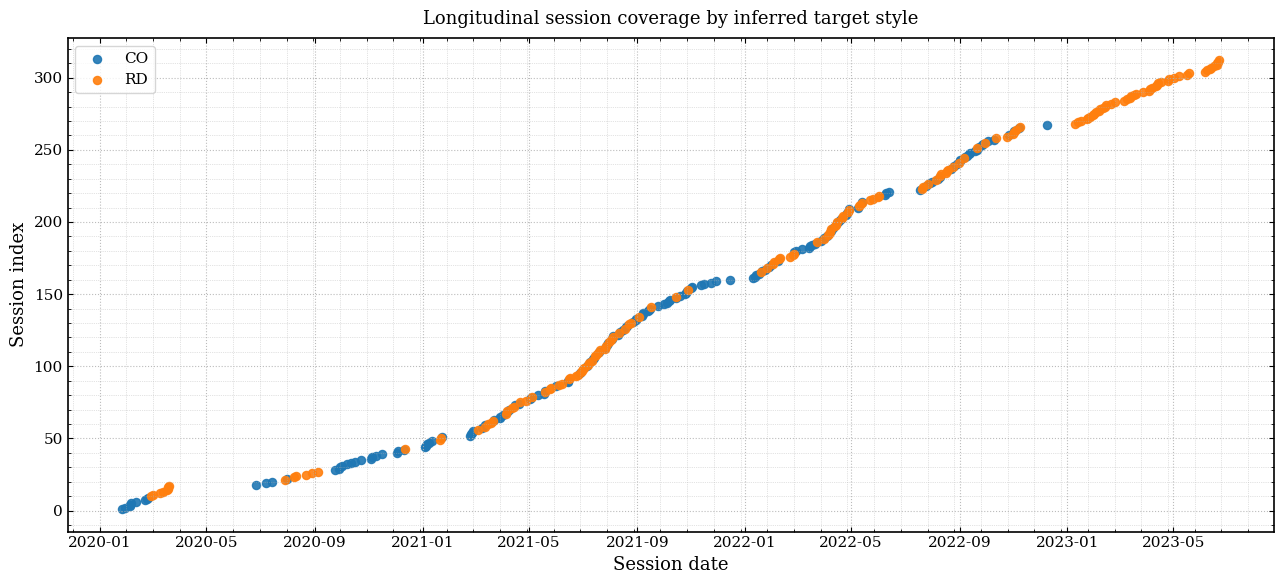

In [14]:
fig, ax = plt.subplots(figsize=(13, 6))

for style, subdf in session_master_df.groupby("target_style_inferred"):
    ax.scatter(
        subdf["session_date"],
        subdf["session_index"],
        s=34,
        label=style,
        alpha=0.9
    )

ax.set_xlabel("Session date")
ax.set_ylabel("Session index")
ax.set_title("Longitudinal session coverage by inferred target style", pad=10)
paper_axes(ax)
ax.legend(loc="best")

plt.tight_layout()
plt.savefig(OUT_FIG_DIR / "fig01_session_coverage_by_target_style.png", dpi=300, bbox_inches="tight")
plt.savefig(OUT_FIG_DIR / "fig01_session_coverage_by_target_style.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Extract the full trial catalog

We now read the `trials` table from every NWB file and standardize the columns into one combined trial-level table.

In [15]:
nwb_files = sorted(DATASET_DIR.glob("*_ecephys.nwb"))
assert len(nwb_files) > 0, "No NWB files found."

session_lookup = session_master_df.set_index("file_name").to_dict(orient="index")

trial_tables = []

for i, nwb_path in enumerate(nwb_files, start=1):
    if i % 25 == 0 or i == 1 or i == len(nwb_files):
        print(f"Reading trials {i}/{len(nwb_files)}: {nwb_path.name}")

    trials_df = safe_read_trials(nwb_path)

    if trials_df.empty:
        continue

    meta = session_lookup.get(nwb_path.name, {})
    trials_df["file_name"] = nwb_path.name
    trials_df["file_path"] = str(nwb_path)
    trials_df["session_date"] = meta.get("session_date", pd.NaT)
    trials_df["session_index"] = meta.get("session_index", np.nan)
    trials_df["identifier"] = meta.get("identifier", None)
    trials_df["target_style_inferred"] = meta.get("target_style_inferred", "UNKNOWN")

    if "start_time" in trials_df.columns and "stop_time" in trials_df.columns:
        trials_df["trial_duration"] = trials_df["stop_time"] - trials_df["start_time"]
    else:
        trials_df["trial_duration"] = np.nan

    if "timeseries" in trials_df.columns:
        trials_df["timeseries_n_items"] = trials_df["timeseries"].apply(
            lambda x: len(x) if hasattr(x, "__len__") else np.nan
        )

    trial_tables.append(trials_df)

trial_catalog_df = pd.concat(trial_tables, ignore_index=True, sort=False)
trial_catalog_df["session_date"] = pd.to_datetime(trial_catalog_df["session_date"], errors="coerce")

print("trial_catalog_df shape:", trial_catalog_df.shape)
display(trial_catalog_df.head())

Reading trials 1/312: sub-Monkey-N_ses-20200127_ecephys.nwb
Reading trials 25/312: sub-Monkey-N_ses-20200822_ecephys.nwb
Reading trials 50/312: sub-Monkey-N_ses-20210122_ecephys.nwb
Reading trials 75/312: sub-Monkey-N_ses-20210421_ecephys.nwb
Reading trials 100/312: sub-Monkey-N_ses-20210706_ecephys.nwb
Reading trials 125/312: sub-Monkey-N_ses-20210816_ecephys.nwb
Reading trials 150/312: sub-Monkey-N_ses-20211025_ecephys.nwb
Reading trials 175/312: sub-Monkey-N_ses-20220210_ecephys.nwb
Reading trials 200/312: sub-Monkey-N_ses-20220415_obj-y4c3g5_ecephys.nwb
Reading trials 225/312: sub-Monkey-N_ses-20220725_ecephys.nwb
Reading trials 250/312: sub-Monkey-N_ses-20220921_obj-1k78ex8_ecephys.nwb
Reading trials 275/312: sub-Monkey-N_ses-20230131_ecephys.nwb
Reading trials 300/312: sub-Monkey-N_ses-20230502_ecephys.nwb
Reading trials 312/312: sub-Monkey-N_ses-20230622_ecephys.nwb
trial_catalog_df shape: (117000, 19)


,id,start_time,stop_time,trial_number,trial_count,run_id,index_target_position,mrs_target_position,target_style,trial_timeout,timeseries,file_name,file_path,session_date,session_index,identifier,target_style_inferred,trial_duration,timeseries_n_items
0,0,8.41,9.67,6.0,64,3,0.3,0.3,CO,30000.0,"[(0, 63, index_position pynwb.base.TimeSeries ...",sub-Monkey-N_ses-20200127_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-01-27,1,2020-01-27_CO_nwb,CO,1.26,6
1,1,9.69,11.05,7.0,69,3,0.5,0.5,CO,30000.0,"[(64, 68, index_position pynwb.base.TimeSeries...",sub-Monkey-N_ses-20200127_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-01-27,1,2020-01-27_CO_nwb,CO,1.36,6
2,2,11.07,12.95,8.0,95,3,0.7,0.5,CO,30000.0,"[(133, 94, index_position pynwb.base.TimeSerie...",sub-Monkey-N_ses-20200127_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-01-27,1,2020-01-27_CO_nwb,CO,1.88,6
3,3,12.97,13.77,9.0,41,3,0.5,0.5,CO,30000.0,"[(228, 40, index_position pynwb.base.TimeSerie...",sub-Monkey-N_ses-20200127_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-01-27,1,2020-01-27_CO_nwb,CO,0.80,6
4,4,13.79,17.01,10.0,162,3,0.2,0.8,CO,30000.0,"[(269, 161, index_position pynwb.base.TimeSeri...",sub-Monkey-N_ses-20200127_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-01-27,1,2020-01-27_CO_nwb,CO,3.22,6


In [16]:
preferred_col_order = [
    "file_name", "session_index", "session_date", "identifier", "target_style_inferred",
    "id", "start_time", "stop_time", "trial_duration",
    "trial_number", "trial_count", "run_id",
    "index_target_position", "mrs_target_position", "target_style",
    "trial_timeout", "timeseries_n_items", "file_path"
]

existing_cols = [c for c in preferred_col_order if c in trial_catalog_df.columns]
remaining_cols = [c for c in trial_catalog_df.columns if c not in existing_cols]
trial_catalog_df = trial_catalog_df[existing_cols + remaining_cols]

trial_catalog_df.to_csv(OUT_TABLE_DIR / "trial_catalog_all_sessions.csv", index=False)
display(trial_catalog_df.head(10))

,file_name,session_index,session_date,identifier,target_style_inferred,id,start_time,stop_time,trial_duration,trial_number,trial_count,run_id,index_target_position,mrs_target_position,target_style,trial_timeout,timeseries_n_items,file_path,timeseries
0,sub-Monkey-N_ses-20200127_ecephys.nwb,1,2020-01-27,2020-01-27_CO_nwb,CO,0,8.41,9.67,1.26,6.0,64,3,0.3,0.3,CO,30000.0,6,/kaggle/input/datasets/katakuricharlotte/dandi...,"[(0, 63, index_position pynwb.base.TimeSeries ..."
1,sub-Monkey-N_ses-20200127_ecephys.nwb,1,2020-01-27,2020-01-27_CO_nwb,CO,1,9.69,11.05,1.36,7.0,69,3,0.5,0.5,CO,30000.0,6,/kaggle/input/datasets/katakuricharlotte/dandi...,"[(64, 68, index_position pynwb.base.TimeSeries..."
2,sub-Monkey-N_ses-20200127_ecephys.nwb,1,2020-01-27,2020-01-27_CO_nwb,CO,2,11.07,12.95,1.88,8.0,95,3,0.7,0.5,CO,30000.0,6,/kaggle/input/datasets/katakuricharlotte/dandi...,"[(133, 94, index_position pynwb.base.TimeSerie..."
3,sub-Monkey-N_ses-20200127_ecephys.nwb,1,2020-01-27,2020-01-27_CO_nwb,CO,3,12.97,13.77,0.80,9.0,41,3,0.5,0.5,CO,30000.0,6,/kaggle/input/datasets/katakuricharlotte/dandi...,"[(228, 40, index_position pynwb.base.TimeSerie..."
4,sub-Monkey-N_ses-20200127_ecephys.nwb,1,2020-01-27,2020-01-27_CO_nwb,CO,4,13.79,17.01,3.22,10.0,162,3,0.2,0.8,CO,30000.0,6,/kaggle/input/datasets/katakuricharlotte/dandi...,"[(269, 161, index_position pynwb.base.TimeSeri..."
5,sub-Monkey-N_ses-20200127_ecephys.nwb,1,2020-01-27,2020-01-27_CO_nwb,CO,5,17.03,18.47,1.44,11.0,73,3,0.5,0.5,CO,30000.0,6,/kaggle/input/datasets/katakuricharlotte/dandi...,"[(431, 72, index_position pynwb.base.TimeSerie..."
6,sub-Monkey-N_ses-20200127_ecephys.nwb,1,2020-01-27,2020-01-27_CO_nwb,CO,6,18.49,20.09,1.60,12.0,81,3,0.3,0.5,CO,30000.0,6,/kaggle/input/datasets/katakuricharlotte/dandi...,"[(504, 80, index_position pynwb.base.TimeSerie..."
7,sub-Monkey-N_ses-20200127_ecephys.nwb,1,2020-01-27,2020-01-27_CO_nwb,CO,7,20.11,21.99,1.88,13.0,95,3,0.5,0.5,CO,30000.0,6,/kaggle/input/datasets/katakuricharlotte/dandi...,"[(585, 94, index_position pynwb.base.TimeSerie..."
8,sub-Monkey-N_ses-20200127_ecephys.nwb,1,2020-01-27,2020-01-27_CO_nwb,CO,8,22.01,25.71,3.70,14.0,186,3,0.8,0.2,CO,30000.0,6,/kaggle/input/datasets/katakuricharlotte/dandi...,"[(680, 185, index_position pynwb.base.TimeSeri..."
9,sub-Monkey-N_ses-20200127_ecephys.nwb,1,2020-01-27,2020-01-27_CO_nwb,CO,9,25.73,27.27,1.54,15.0,78,3,0.5,0.5,CO,30000.0,6,/kaggle/input/datasets/katakuricharlotte/dandi...,"[(866, 77, index_position pynwb.base.TimeSerie..."


## Session-level trial summary

This condenses the trial catalog into one row per session for later filtering and train/test bookkeeping.

In [17]:
agg_dict = {
    "id": "count",
    "trial_duration": ["mean", "median", "std", "min", "max"],
}

for optional_col in ["trial_number", "trial_count", "run_id", "index_target_position", "mrs_target_position", "target_style", "timeseries_n_items"]:
    if optional_col in trial_catalog_df.columns:
        agg_dict[optional_col] = "nunique"

session_trial_summary = trial_catalog_df.groupby(
    ["file_name", "session_index", "session_date", "target_style_inferred"],
    dropna=False
).agg(agg_dict)

session_trial_summary.columns = [
    "_".join([str(x) for x in col if str(x) != ""]).strip("_")
    for col in session_trial_summary.columns.to_flat_index()
]

session_trial_summary = session_trial_summary.reset_index().rename(columns={"id_count": "n_trials_from_catalog"})
session_trial_summary = session_trial_summary.sort_values("session_date").reset_index(drop=True)

session_trial_summary.to_csv(OUT_TABLE_DIR / "session_trial_summary.csv", index=False)
display(session_trial_summary.head(15))

,file_name,session_index,session_date,target_style_inferred,n_trials_from_catalog,trial_duration_mean,trial_duration_median,trial_duration_std,trial_duration_min,trial_duration_max,trial_number_nunique,trial_count_nunique,run_id_nunique,index_target_position_nunique,mrs_target_position_nunique,target_style_nunique,timeseries_n_items_nunique
0,sub-Monkey-N_ses-20200127_ecephys.nwb,1,2020-01-27,CO,375,1.454645,1.280,0.582455,0.800,5.90,375,82,1,7,7,1,1
1,sub-Monkey-N_ses-20200130_ecephys.nwb,2,2020-01-30,CO,375,1.417008,1.280,0.479237,0.919,4.40,375,78,1,7,7,1,1
2,sub-Monkey-N_ses-20200204_ecephys.nwb,3,2020-02-04,CO,375,1.390211,1.260,0.419824,0.940,3.38,375,76,1,7,7,1,1
3,sub-Monkey-N_ses-20200205_ecephys.nwb,4,2020-02-05,CO,375,1.397133,1.280,0.427517,0.860,4.16,375,75,1,7,7,1,1
4,sub-Monkey-N_ses-20200206_ecephys.nwb,5,2020-02-06,CO,375,1.417712,1.201,0.563885,0.840,4.86,375,89,1,7,7,1,1
5,sub-Monkey-N_ses-20200211_ecephys.nwb,6,2020-02-11,CO,375,1.422691,1.320,0.397859,1.000,3.42,375,70,1,7,7,1,1
6,sub-Monkey-N_ses-20200222_ecephys.nwb,7,2020-02-22,CO,375,1.362520,1.221,0.499423,0.860,5.34,375,71,1,7,7,1,1
7,sub-Monkey-N_ses-20200224_ecephys.nwb,8,2020-02-24,CO,375,1.258552,1.180,0.305253,0.879,2.90,375,59,1,7,7,1,1
8,sub-Monkey-N_ses-20200225_ecephys.nwb,9,2020-02-25,CO,375,1.399800,1.260,0.488039,0.820,4.70,375,80,1,7,7,1,1
9,sub-Monkey-N_ses-20200228_ecephys.nwb,10,2020-02-28,RD,375,1.660128,1.520,0.568217,0.720,5.66,375,96,1,375,375,1,1


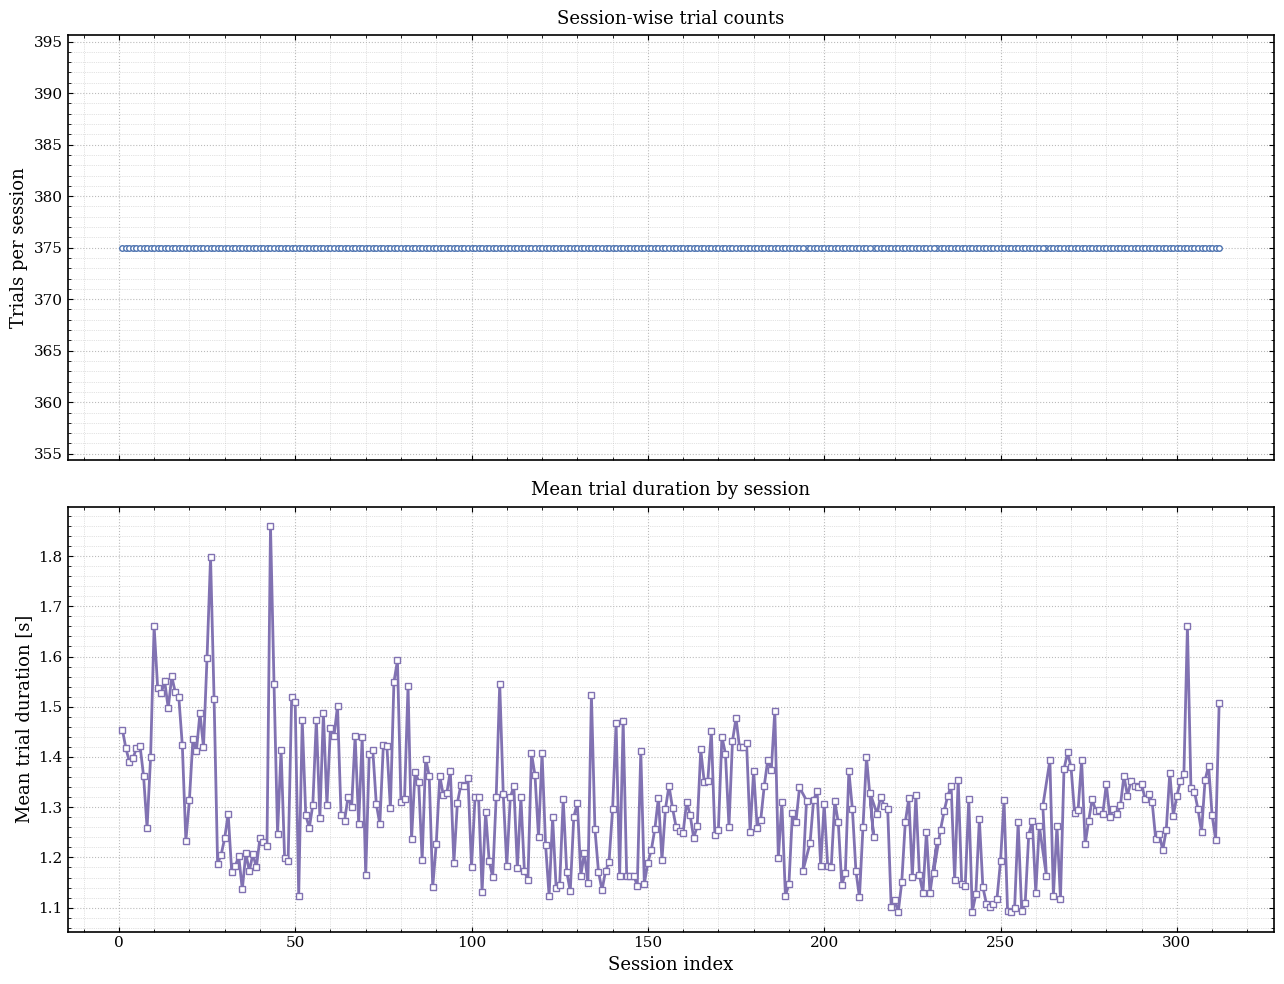

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

axes[0].plot(
    session_trial_summary["session_index"],
    session_trial_summary["n_trials_from_catalog"],
    color="#4C72B0",
    lw=2,
    marker="o",
    ms=4,
    markerfacecolor="white"
)
axes[0].set_ylabel("Trials per session")
axes[0].set_title("Session-wise trial counts", pad=8)
paper_axes(axes[0])

axes[1].plot(
    session_trial_summary["session_index"],
    session_trial_summary["trial_duration_mean"],
    color="#8172B2",
    lw=2,
    marker="s",
    ms=4,
    markerfacecolor="white"
)
axes[1].set_xlabel("Session index")
axes[1].set_ylabel("Mean trial duration [s]")
axes[1].set_title("Mean trial duration by session", pad=8)
paper_axes(axes[1])

plt.tight_layout()
plt.savefig(OUT_FIG_DIR / "fig02_trial_count_and_duration_by_session.png", dpi=300, bbox_inches="tight")
plt.savefig(OUT_FIG_DIR / "fig02_trial_count_and_duration_by_session.pdf", dpi=300, bbox_inches="tight")
plt.show()

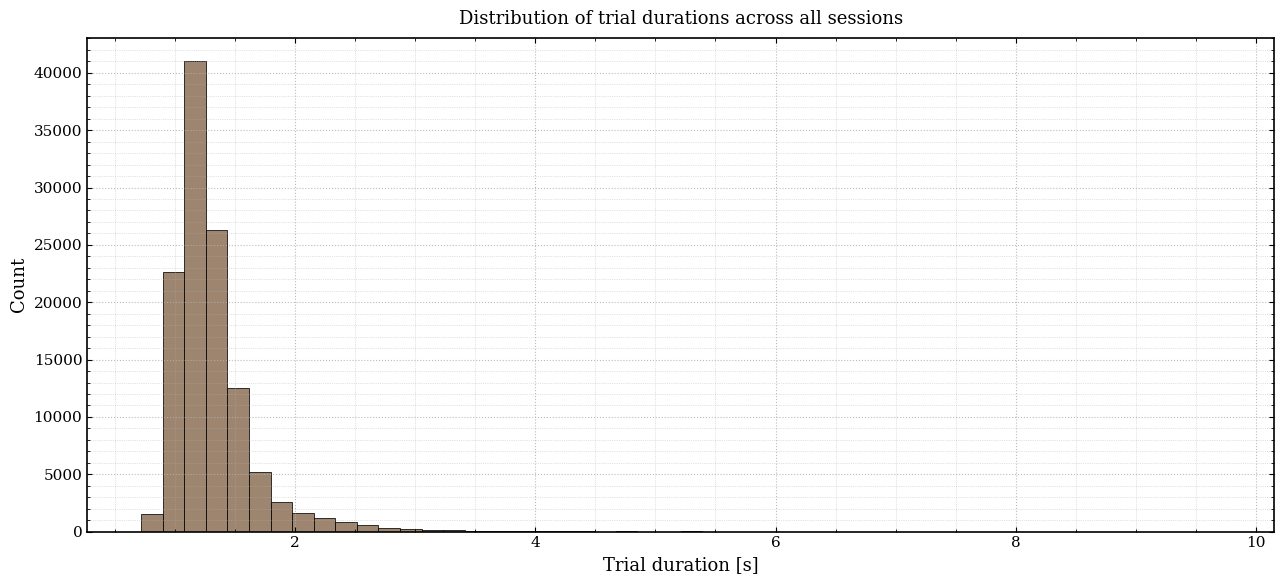

In [19]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.hist(
    trial_catalog_df["trial_duration"].dropna(),
    bins=50,
    color="#937860",
    edgecolor="black",
    linewidth=0.6,
    alpha=0.9
)

ax.set_xlabel("Trial duration [s]")
ax.set_ylabel("Count")
ax.set_title("Distribution of trial durations across all sessions", pad=10)
paper_axes(ax)

plt.tight_layout()
plt.savefig(OUT_FIG_DIR / "fig03_all_trial_durations.png", dpi=300, bbox_inches="tight")
plt.savefig(OUT_FIG_DIR / "fig03_all_trial_durations.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Column stability and missingness

This step checks whether the trial schema is stable enough for a single downstream preprocessing pipeline.

In [21]:
def make_hashable(x):
    if isinstance(x, list):
        return tuple(make_hashable(i) for i in x)
    if isinstance(x, dict):
        return tuple(sorted((k, make_hashable(v)) for k, v in x.items()))
    if isinstance(x, set):
        return tuple(sorted(make_hashable(i) for i in x))
    return x

def safe_nunique(series, dropna=True):
    s = series.dropna() if dropna else series.copy()
    try:
        return s.nunique(dropna=dropna)
    except TypeError:
        return s.map(make_hashable).nunique(dropna=dropna)

trial_column_presence = pd.DataFrame({
    "column": trial_catalog_df.columns,
    "n_missing": trial_catalog_df.isna().sum().values,
    "pct_missing": (100 * trial_catalog_df.isna().mean()).round(2).values,
    "n_unique": [safe_nunique(trial_catalog_df[c], dropna=True) for c in trial_catalog_df.columns],
    "dtype": trial_catalog_df.dtypes.astype(str).values,
}).sort_values(["pct_missing", "n_unique"], ascending=[False, False])

trial_column_presence.to_csv(OUT_TABLE_DIR / "trial_column_presence.csv", index=False)
display(trial_column_presence.head(25))

,column,n_missing,pct_missing,n_unique,dtype
18,timeseries,0,0.0,117000,object
7,stop_time,0,0.0,104905,float64
6,start_time,0,0.0,104877,float64
13,mrs_target_position,0,0.0,53262,float32
12,index_target_position,0,0.0,53260,float32
8,trial_duration,0,0.0,2149,float64
9,trial_number,0,0.0,439,float64
5,id,0,0.0,375,int64
0,file_name,0,0.0,312,object
1,session_index,0,0.0,312,int64


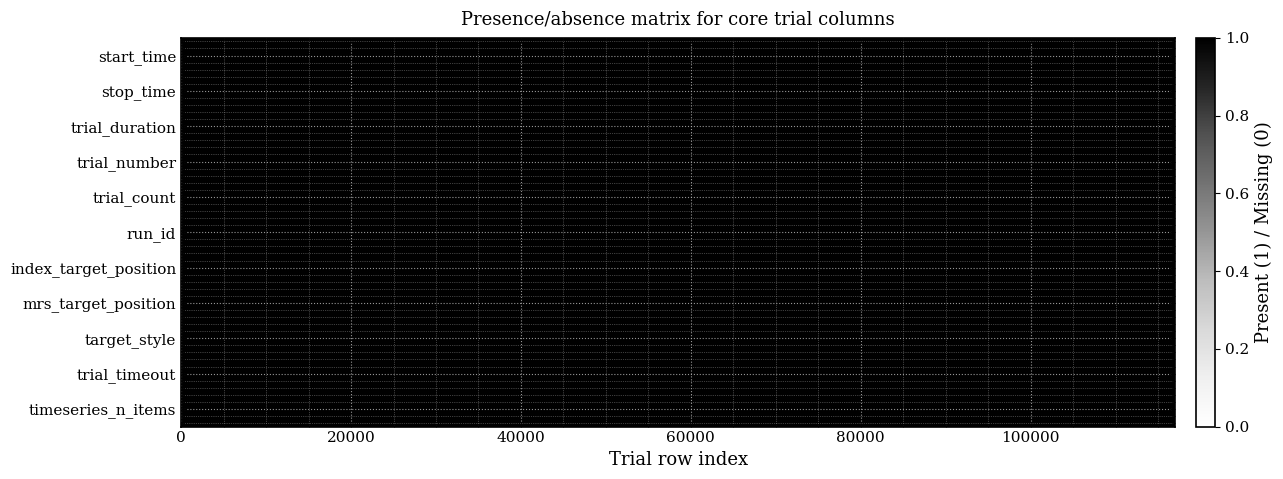

In [22]:
core_cols = [c for c in [
    "start_time", "stop_time", "trial_duration", "trial_number", "trial_count",
    "run_id", "index_target_position", "mrs_target_position", "target_style",
    "trial_timeout", "timeseries_n_items"
] if c in trial_catalog_df.columns]

presence_matrix = trial_catalog_df[core_cols].notna().astype(int)

fig, ax = plt.subplots(figsize=(13, max(4, 0.45 * len(core_cols))))
im = ax.imshow(presence_matrix.T.values, aspect="auto", cmap="Greys", vmin=0, vmax=1)

ax.set_yticks(range(len(core_cols)))
ax.set_yticklabels(core_cols)
ax.set_xlabel("Trial row index")
ax.set_title("Presence/absence matrix for core trial columns", pad=10)
paper_axes(ax)

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Present (1) / Missing (0)")

plt.tight_layout()
plt.savefig(OUT_FIG_DIR / "fig04_trial_column_presence_matrix.png", dpi=300, bbox_inches="tight")
plt.savefig(OUT_FIG_DIR / "fig04_trial_column_presence_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

,column,n_missing,pct_missing
0,start_time,0,0.0
1,stop_time,0,0.0
2,trial_duration,0,0.0
3,trial_number,0,0.0
4,trial_count,0,0.0
5,run_id,0,0.0
6,index_target_position,0,0.0
7,mrs_target_position,0,0.0
8,target_style,0,0.0
9,trial_timeout,0,0.0


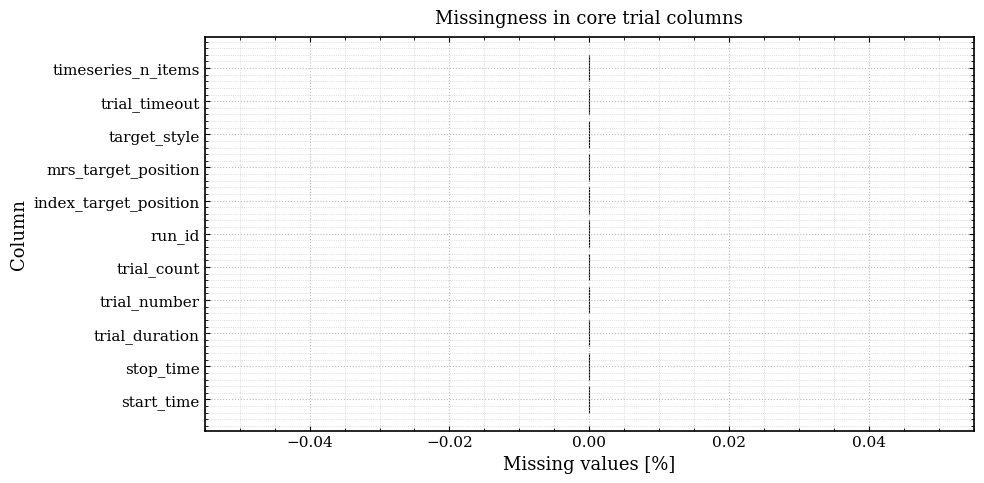

In [29]:
missing_summary = pd.DataFrame({
    "column": core_cols,
    "n_missing": [trial_catalog_df[c].isna().sum() for c in core_cols],
    "pct_missing": [100 * trial_catalog_df[c].isna().mean() for c in core_cols]
}).sort_values("pct_missing", ascending=False)

display(missing_summary)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    missing_summary["column"],
    missing_summary["pct_missing"],
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.8
)
ax.set_xlabel("Missing values [%]")
ax.set_ylabel("Column")
ax.set_title("Missingness in core trial columns", pad=10)
paper_axes(ax)

plt.tight_layout()
plt.savefig(OUT_FIG_DIR / "fig04b_core_trial_missingness_summary.png", dpi=300, bbox_inches="tight")
plt.savefig(OUT_FIG_DIR / "fig04b_core_trial_missingness_summary.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Decoder-ready exports

These exports are intentionally simple and stable so the next notebook can focus on feature construction and model evaluation.

In [23]:
decoder_session_index = session_master_df.merge(
    session_trial_summary[
        ["file_name", "n_trials_from_catalog", "trial_duration_mean", "trial_duration_median", "trial_duration_std"]
    ],
    on="file_name",
    how="left"
)

decoder_session_index["session_keep"] = (
    decoder_session_index["trials_present"].fillna(False).astype(bool)
    & (decoder_session_index["n_trials_from_catalog"].fillna(0) > 0)
)

decoder_session_index.to_csv(OUT_TABLE_DIR / "decoder_session_index.csv", index=False)
display(decoder_session_index.head(15))

,file_name,file_path,session_date,identifier,session_description,session_start_time,institution,lab,subject_id,subject_species,...,units_present,electrodes_present,target_style_inferred,session_index,days_since_first_session,n_trials_from_catalog,trial_duration_mean,trial_duration_median,trial_duration_std,session_keep
0,sub-Monkey-N_ses-20200127_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-01-27,2020-01-27_CO_nwb,Neural and behavioral data for target style CO,2020-01-27 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,False,True,CO,1,0,375,1.454645,1.280,0.582455,True
1,sub-Monkey-N_ses-20200130_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-01-30,2020-01-30_CO_nwb,Neural and behavioral data for target style CO,2020-01-30 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,False,True,CO,2,3,375,1.417008,1.280,0.479237,True
2,sub-Monkey-N_ses-20200204_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-04,2020-02-04_CO_nwb,Neural and behavioral data for target style CO,2020-02-04 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,False,True,CO,3,8,375,1.390211,1.260,0.419824,True
3,sub-Monkey-N_ses-20200205_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-05,2020-02-05_CO_nwb,Neural and behavioral data for target style CO,2020-02-05 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,False,True,CO,4,9,375,1.397133,1.280,0.427517,True
4,sub-Monkey-N_ses-20200206_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-06,2020-02-06_CO_nwb,Neural and behavioral data for target style CO,2020-02-06 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,False,True,CO,5,10,375,1.417712,1.201,0.563885,True
5,sub-Monkey-N_ses-20200211_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-11,2020-02-11_CO_nwb,Neural and behavioral data for target style CO,2020-02-11 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,False,True,CO,6,15,375,1.422691,1.320,0.397859,True
6,sub-Monkey-N_ses-20200222_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-22,2020-02-22_CO_nwb,Neural and behavioral data for target style CO,2020-02-22 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,False,True,CO,7,26,375,1.362520,1.221,0.499423,True
7,sub-Monkey-N_ses-20200224_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-24,2020-02-24_CO_nwb,Neural and behavioral data for target style CO,2020-02-24 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,False,True,CO,8,28,375,1.258552,1.180,0.305253,True
8,sub-Monkey-N_ses-20200225_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-25,2020-02-25_CO_nwb,Neural and behavioral data for target style CO,2020-02-25 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,False,True,CO,9,29,375,1.399800,1.260,0.488039,True
9,sub-Monkey-N_ses-20200228_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-28,2020-02-28_RD_nwb,Neural and behavioral data for target style RD,2020-02-28 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,False,True,RD,10,32,375,1.660128,1.520,0.568217,True


In [24]:
decoder_trial_table = trial_catalog_df.copy()

drop_if_present = ["timeseries"]
existing_drop = [c for c in drop_if_present if c in decoder_trial_table.columns]
if existing_drop:
    decoder_trial_table = decoder_trial_table.drop(columns=existing_drop)

decoder_trial_table.to_csv(OUT_TABLE_DIR / "decoder_trial_table.csv", index=False)
print("decoder_trial_table shape:", decoder_trial_table.shape)
display(decoder_trial_table.head(10))

decoder_trial_table shape: (117000, 18)


,file_name,session_index,session_date,identifier,target_style_inferred,id,start_time,stop_time,trial_duration,trial_number,trial_count,run_id,index_target_position,mrs_target_position,target_style,trial_timeout,timeseries_n_items,file_path
0,sub-Monkey-N_ses-20200127_ecephys.nwb,1,2020-01-27,2020-01-27_CO_nwb,CO,0,8.41,9.67,1.26,6.0,64,3,0.3,0.3,CO,30000.0,6,/kaggle/input/datasets/katakuricharlotte/dandi...
1,sub-Monkey-N_ses-20200127_ecephys.nwb,1,2020-01-27,2020-01-27_CO_nwb,CO,1,9.69,11.05,1.36,7.0,69,3,0.5,0.5,CO,30000.0,6,/kaggle/input/datasets/katakuricharlotte/dandi...
2,sub-Monkey-N_ses-20200127_ecephys.nwb,1,2020-01-27,2020-01-27_CO_nwb,CO,2,11.07,12.95,1.88,8.0,95,3,0.7,0.5,CO,30000.0,6,/kaggle/input/datasets/katakuricharlotte/dandi...
3,sub-Monkey-N_ses-20200127_ecephys.nwb,1,2020-01-27,2020-01-27_CO_nwb,CO,3,12.97,13.77,0.80,9.0,41,3,0.5,0.5,CO,30000.0,6,/kaggle/input/datasets/katakuricharlotte/dandi...
4,sub-Monkey-N_ses-20200127_ecephys.nwb,1,2020-01-27,2020-01-27_CO_nwb,CO,4,13.79,17.01,3.22,10.0,162,3,0.2,0.8,CO,30000.0,6,/kaggle/input/datasets/katakuricharlotte/dandi...
5,sub-Monkey-N_ses-20200127_ecephys.nwb,1,2020-01-27,2020-01-27_CO_nwb,CO,5,17.03,18.47,1.44,11.0,73,3,0.5,0.5,CO,30000.0,6,/kaggle/input/datasets/katakuricharlotte/dandi...
6,sub-Monkey-N_ses-20200127_ecephys.nwb,1,2020-01-27,2020-01-27_CO_nwb,CO,6,18.49,20.09,1.60,12.0,81,3,0.3,0.5,CO,30000.0,6,/kaggle/input/datasets/katakuricharlotte/dandi...
7,sub-Monkey-N_ses-20200127_ecephys.nwb,1,2020-01-27,2020-01-27_CO_nwb,CO,7,20.11,21.99,1.88,13.0,95,3,0.5,0.5,CO,30000.0,6,/kaggle/input/datasets/katakuricharlotte/dandi...
8,sub-Monkey-N_ses-20200127_ecephys.nwb,1,2020-01-27,2020-01-27_CO_nwb,CO,8,22.01,25.71,3.70,14.0,186,3,0.8,0.2,CO,30000.0,6,/kaggle/input/datasets/katakuricharlotte/dandi...
9,sub-Monkey-N_ses-20200127_ecephys.nwb,1,2020-01-27,2020-01-27_CO_nwb,CO,9,25.73,27.27,1.54,15.0,78,3,0.5,0.5,CO,30000.0,6,/kaggle/input/datasets/katakuricharlotte/dandi...


In [25]:
target_style_trial_counts = trial_catalog_df.groupby("target_style_inferred").size().rename("n_trials").reset_index()
target_style_trial_counts.to_csv(OUT_TABLE_DIR / "target_style_trial_counts.csv", index=False)
display(target_style_trial_counts)

,target_style_inferred,n_trials
0,CO,58500
1,RD,58500


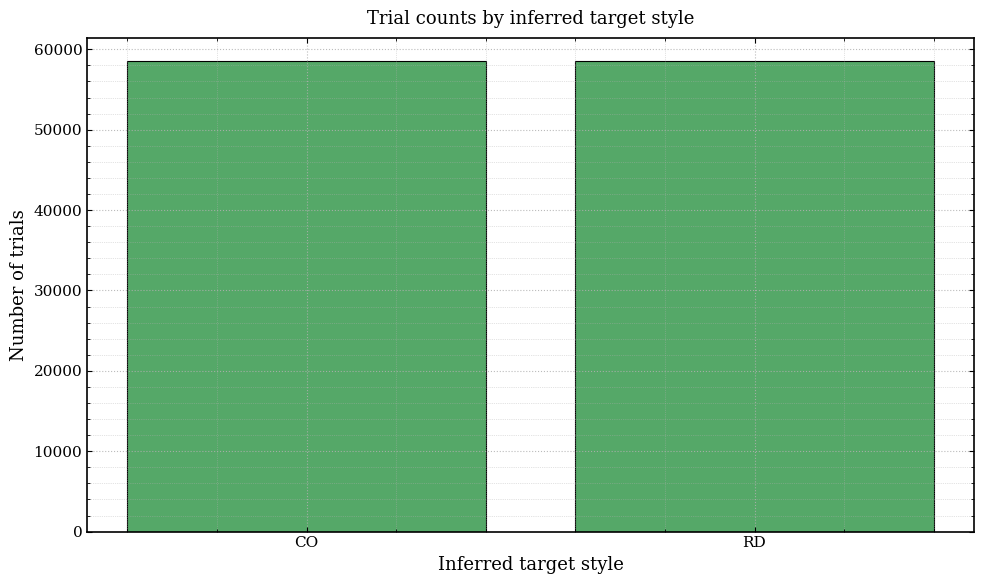

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    target_style_trial_counts["target_style_inferred"],
    target_style_trial_counts["n_trials"],
    color="#55A868",
    edgecolor="black",
    linewidth=0.8
)

ax.set_xlabel("Inferred target style")
ax.set_ylabel("Number of trials")
ax.set_title("Trial counts by inferred target style", pad=10)
paper_axes(ax)

plt.tight_layout()
plt.savefig(OUT_FIG_DIR / "fig05_trial_counts_by_target_style.png", dpi=300, bbox_inches="tight")
plt.savefig(OUT_FIG_DIR / "fig05_trial_counts_by_target_style.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Notebook report

Write a compact record of what was built here so later notebooks can validate their inputs before running.

In [27]:
report = {
    "dataset_dir": str(DATASET_DIR),
    "n_sessions_in_master_index": int(len(session_master_df)),
    "n_sessions_with_trials": int(session_master_df["trials_present"].fillna(False).sum()),
    "n_sessions_with_units": int(session_master_df["units_present"].fillna(False).sum()),
    "n_rows_trial_catalog": int(len(trial_catalog_df)),
    "n_rows_decoder_trial_table": int(len(decoder_trial_table)),
    "target_styles_detected": sorted([str(x) for x in trial_catalog_df["target_style_inferred"].dropna().unique().tolist()]),
    "output_tables_dir": str(OUT_TABLE_DIR),
    "output_figures_dir": str(OUT_FIG_DIR),
}

with open(OUT_META_DIR / "session_index_report.json", "w") as f:
    json.dump(report, f, indent=2, default=str)

report_lines = [
    "SESSION INDEX REPORT",
    f"Dataset directory: {report['dataset_dir']}",
    f"Sessions in master index: {report['n_sessions_in_master_index']}",
    f"Sessions with trials: {report['n_sessions_with_trials']}",
    f"Sessions with units: {report['n_sessions_with_units']}",
    f"Rows in trial catalog: {report['n_rows_trial_catalog']}",
    f"Rows in decoder trial table: {report['n_rows_decoder_trial_table']}",
    f"Target styles detected: {', '.join(report['target_styles_detected'])}",
    f"Output tables dir: {report['output_tables_dir']}",
    f"Output figures dir: {report['output_figures_dir']}",
]

report_text = "\n".join(report_lines)

with open(OUT_META_DIR / "session_index_report.txt", "w") as f:
    f.write(report_text)

print(report_text)

SESSION INDEX REPORT
Dataset directory: /kaggle/input/datasets/katakuricharlotte/dandi-dataset/001201/sub-Monkey-N
Sessions in master index: 312
Sessions with trials: 312
Sessions with units: 0
Rows in trial catalog: 117000
Rows in decoder trial table: 117000
Target styles detected: CO, RD
Output tables dir: /kaggle/working/tables_session_index
Output figures dir: /kaggle/working/figures_session_index


In [28]:
print("Generated tables:")
for p in sorted(OUT_TABLE_DIR.glob("*")):
    print(" -", p.name)

print("\nGenerated figures:")
for p in sorted(OUT_FIG_DIR.glob("*")):
    print(" -", p.name)

print("\nGenerated metadata:")
for p in sorted(OUT_META_DIR.glob("*")):
    print(" -", p.name)

Generated tables:
 - decoder_session_index.csv
 - decoder_trial_table.csv
 - session_master_index.csv
 - session_trial_summary.csv
 - target_style_session_counts.csv
 - target_style_trial_counts.csv
 - trial_catalog_all_sessions.csv
 - trial_column_presence.csv

Generated figures:
 - fig01_session_coverage_by_target_style.pdf
 - fig01_session_coverage_by_target_style.png
 - fig02_trial_count_and_duration_by_session.pdf
 - fig02_trial_count_and_duration_by_session.png
 - fig03_all_trial_durations.pdf
 - fig03_all_trial_durations.png
 - fig04_trial_column_presence_matrix.pdf
 - fig04_trial_column_presence_matrix.png
 - fig05_trial_counts_by_target_style.pdf
 - fig05_trial_counts_by_target_style.png

Generated metadata:
 - session_index_report.json
 - session_index_report.txt
